# EDA — Hospital Operations Data

Exploratory analysis of the constraint-aware, repaired synthetic dataset shipped in `app/data/` (large scale: 8,000 patients, 12,000 admissions). This notebook reads only the exported CSVs — no database connection required, so it runs identically for anyone who clones the repo.

For how this data was generated and repaired (and the real bugs found along the way), see [`docs/METHODOLOGY.md`](../docs/METHODOLOGY.md).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#c3c2b7"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["grid.linewidth"] = 0.8
plt.rcParams["font.size"] = 10

DATA_DIR = Path("../app/data")
BLUE = "#2a78d6"


## Load data

In [2]:
tables = [
    "departments", "payers", "procedures", "patients", "doctors", "nurses",
    "employees", "rooms", "admissions", "triage", "diagnoses",
    "patient_procedures", "medications", "medical_tests", "staff_shifts",
    "billing", "billing_line_items", "icd10_lookup",
]

data = {t: pd.read_csv(DATA_DIR / f"{t}.csv") for t in tables}

for date_col_table, cols in {
    "admissions": ["admission_date", "discharge_date"],
    "billing": ["bill_date", "due_date", "payment_date"],
    "diagnoses": ["diagnosis_date"],
}.items():
    for c in cols:
        data[date_col_table][c] = pd.to_datetime(data[date_col_table][c], errors="coerce")

for t in tables:
    print(f"{t:<22} {len(data[t]):>7,} rows")


departments                 20 rows
payers                      10 rows
procedures                  30 rows
patients                 8,000 rows
doctors                    350 rows
nurses                     900 rows
employees                  500 rows
rooms                      560 rows
admissions              12,000 rows
triage                   8,148 rows
diagnoses               21,774 rows
patient_procedures      12,198 rows
medications             18,515 rows
medical_tests           15,176 rows
staff_shifts            21,000 rows
billing                  9,617 rows
billing_line_items      38,826 rows
icd10_lookup                66 rows


## Admissions over time

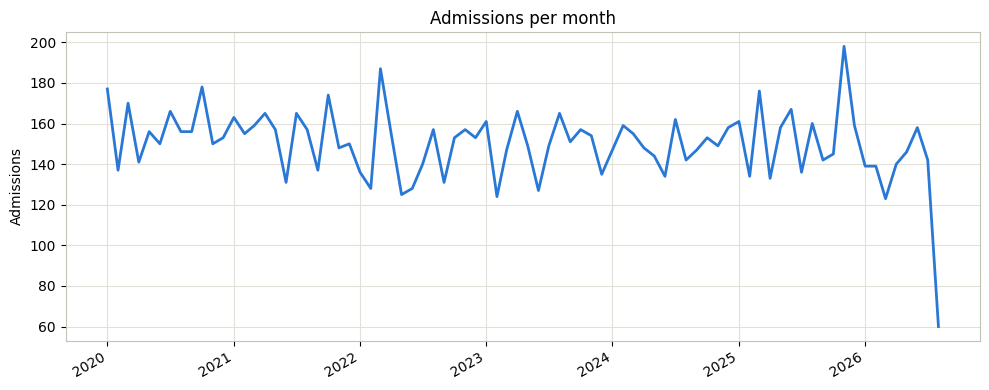

Date range: 2020-01-01 to 2026-08-09
Average admissions/month: 150


In [3]:
admissions = data["admissions"]

monthly = admissions.set_index("admission_date").resample("MS").size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly.values, color=BLUE, linewidth=2)
ax.set_title("Admissions per month")
ax.set_ylabel("Admissions")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"Date range: {admissions['admission_date'].min():%Y-%m-%d} to {admissions['admission_date'].max():%Y-%m-%d}")
print(f"Average admissions/month: {monthly.mean():.0f}")


## Admission volume by department

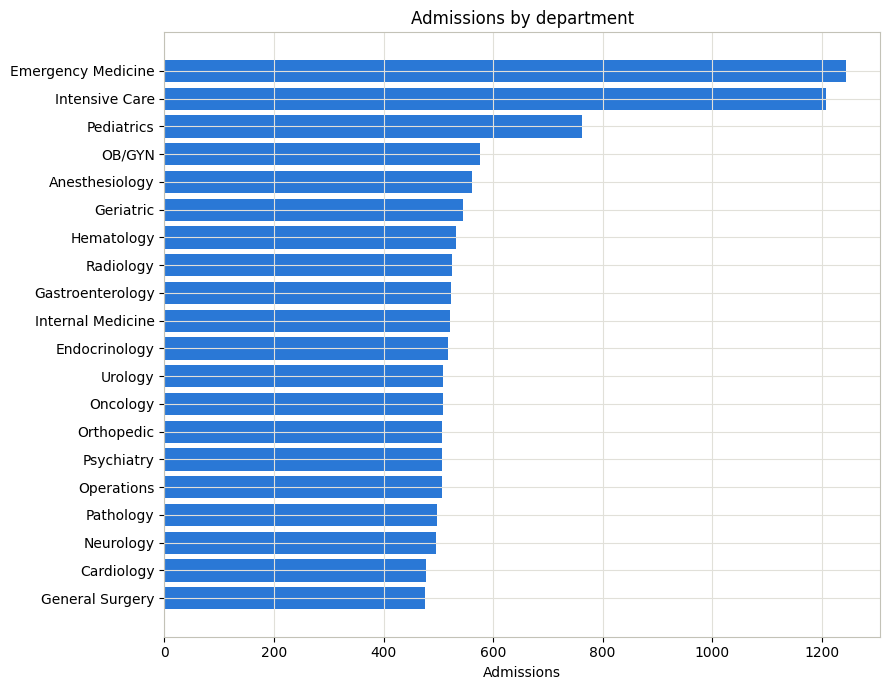

Busiest: Emergency Medicine (1,244 admissions)
Quietest: General Surgery (475 admissions)


In [4]:
dept_vol = (
    admissions.merge(data["departments"], on="department_id")
    .groupby("dep_name").size().sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(dept_vol.index, dept_vol.values, color=BLUE)
ax.set_title("Admissions by department")
ax.set_xlabel("Admissions")
plt.tight_layout()
plt.show()

print(f"Busiest: {dept_vol.idxmax()} ({dept_vol.max():,} admissions)")
print(f"Quietest: {dept_vol.idxmin()} ({dept_vol.min():,} admissions)")


## Length of stay

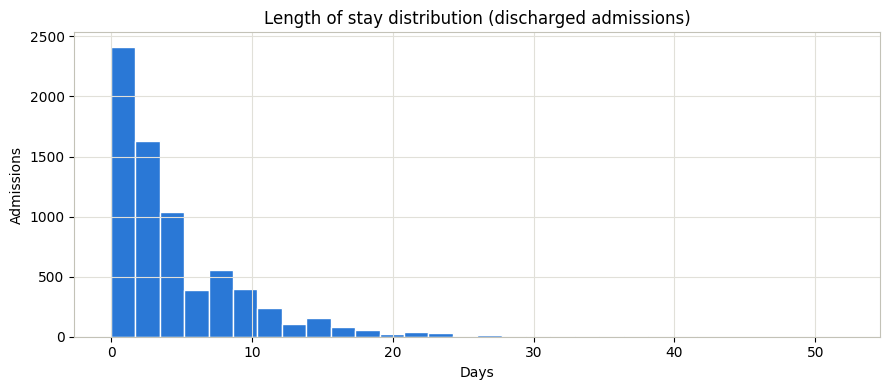

count    7208.0
mean        4.7
std         4.9
min         0.0
25%         1.0
50%         3.0
75%         6.0
90%        11.0
99%        23.0
max        52.0
Name: length_of_stay, dtype: float64


In [5]:
discharged = admissions[admissions["admission_status"] == "Discharged"]
los = discharged["length_of_stay"].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(los, bins=30, color=BLUE, edgecolor="white")
ax.set_title("Length of stay distribution (discharged admissions)")
ax.set_xlabel("Days")
ax.set_ylabel("Admissions")
plt.tight_layout()
plt.show()

print(los.describe(percentiles=[.25, .5, .75, .9, .99]).round(1))


## Patient demographics

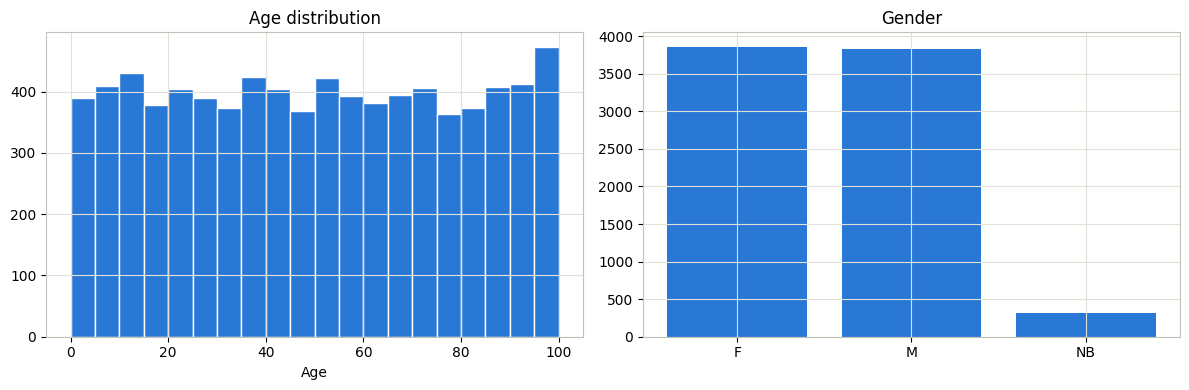

count    8000.0
mean       49.8
std        29.2
min         0.0
25%        24.0
50%        50.0
75%        75.0
max       100.0
Name: age, dtype: float64


In [6]:
patients = data["patients"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(patients["age"], bins=20, color=BLUE, edgecolor="white")
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age")

gender_counts = patients["gender"].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=BLUE)
axes[1].set_title("Gender")

plt.tight_layout()
plt.show()

print(patients["age"].describe().round(1))


## Top 10 diagnoses

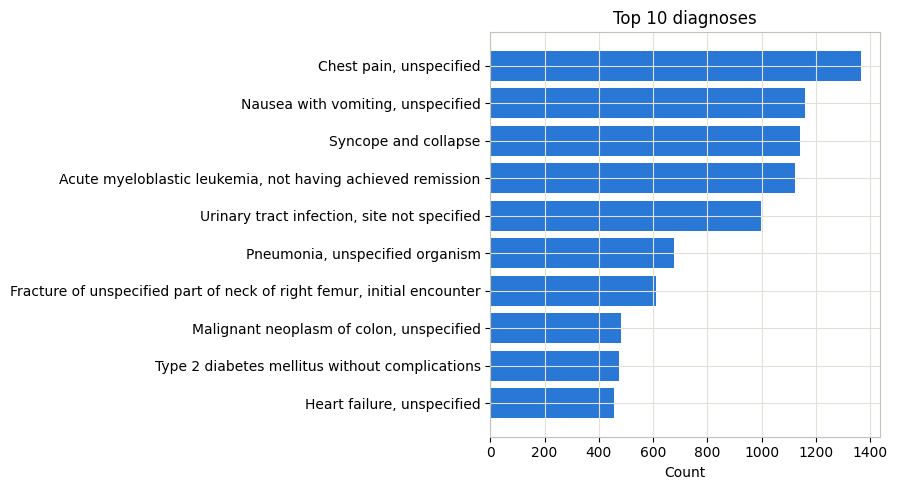

In [7]:
dx = data["diagnoses"].merge(data["icd10_lookup"], on="icd10_code", how="left")
top_dx = dx["diagnosis_name"].value_counts().head(10).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_dx.index, top_dx.values, color=BLUE)
ax.set_title("Top 10 diagnoses")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()


## Financial summary

Total billed:            $240,978,148
Insurance covered:       $161,795,341 (67.1%)
Patient responsibility:  $76,105,651 (31.6%)


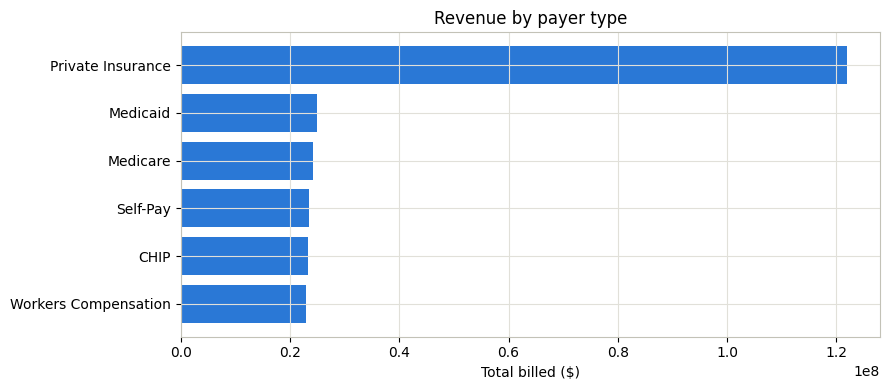

In [8]:
billing = data["billing"]

total_billed = billing["total_amount"].sum()
total_covered = billing["insurance_covered"].sum()
total_patient_resp = billing["patient_responsibility"].sum()

print(f"Total billed:            ${total_billed:,.0f}")
print(f"Insurance covered:       ${total_covered:,.0f} ({total_covered/total_billed:.1%})")
print(f"Patient responsibility:  ${total_patient_resp:,.0f} ({total_patient_resp/total_billed:.1%})")

bill_payer = billing.merge(data["payers"], on="payer_id")
rev_by_payer = bill_payer.groupby("payer_type")["total_amount"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(rev_by_payer.index, rev_by_payer.values, color=BLUE)
ax.set_title("Revenue by payer type")
ax.set_xlabel("Total billed ($)")
plt.tight_layout()
plt.show()


## Takeaways

- Admissions run at a fairly steady monthly pace across the dataset's 6+ year span, with no artificial seasonality injected by the generator.
- Emergency Medicine and Intensive Care dominate admission volume — expected given `ADMISSION_TYPE_P` weights Emergency admissions highest and both departments accept a wide range of patient ages.
- Length of stay is right-skewed (exponential draw in the generator, `scale=5`), consistent with real inpatient LOS distributions.
- Diagnosis frequency reflects the prevalence weights hand-set in `icd10_diagnoses.py`, not a real epidemiological source — see [`docs/CITATIONS.md`](../docs/CITATIONS.md).
- Patient responsibility sits well below total billed, dominated by the payer mix's insurance coverage rates (`PAYER_COVERAGE` in the generator).